# Lib

In [1]:
import os
from pathlib import Path
from PIL import Image
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import torch
import torch.nn as nn
import torch.distributed as dist

from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
    balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize
import math
import random
from collections import defaultdict
from torch.utils.data import Sampler, BatchSampler, DataLoader
import copy


In [2]:
import torch

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))

torch: 2.10.0+cu128
torch cuda: 12.8
cuda available: True
gpu: Tesla T4
capability: (7, 5)


# Data

In [3]:
dataset_dir = Path("/kaggle/input/datasets/duongnguyenquy/mosquitoes-compsci760")
image_dir = dataset_dir / "image_crop/image_crop"
annotation_path = image_dir / "cropped_annotations.csv"

annotations = pd.read_csv(annotation_path)
annotations.head()

,img_fName,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label,source_image
0,train_00000_0_crop.jpeg,340,550,0,0,340,550,albopictus,train_00000.jpeg
1,train_00001_1_crop.jpeg,1050,1093,0,0,1050,1093,albopictus,train_00001.jpeg
2,train_00002_2_crop.jpeg,439,750,0,0,439,750,albopictus,train_00002.jpeg
3,train_00003_3_crop.jpeg,417,462,0,0,417,462,albopictus,train_00003.jpeg
4,train_00004_4_crop.jpeg,568,776,0,0,568,776,culex,train_00004.jpeg


In [4]:
image_df = (
    annotations.groupby("img_fName")["class_label"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

print("Number of images:", len(image_df))
print(image_df["class_label"].value_counts())
image_df.head()

Number of images: 10357
class_label
albopictus            4612
culex                 4563
culiseta               622
japonicus-koreicus     429
anopheles               84
aegypti                 47
Name: count, dtype: int64


,img_fName,class_label
0,train_00000_0_crop.jpeg,albopictus
1,train_00001_1_crop.jpeg,albopictus
2,train_00002_2_crop.jpeg,albopictus
3,train_00003_3_crop.jpeg,albopictus
4,train_00004_4_crop.jpeg,culex


# Preprocessing

In [5]:
label_encoder = LabelEncoder()
image_df["label_id"] = label_encoder.fit_transform(image_df["class_label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print(class_names)
print("Num classes:", num_classes)

['aegypti', 'albopictus', 'anopheles', 'culex', 'culiseta', 'japonicus-koreicus']
Num classes: 6


# Split

In [6]:
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    random_state=42,
    stratify=image_df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_id"]
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))


Train: 7249
Val: 1554
Test: 1554


In [7]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

# Count samples per class
class_counts = train_df["label_id"].value_counts().sort_index()
print(class_counts)

#class_weights = 1.0 / class_counts #tune with different class_weights
class_weights = 1.0 / np.sqrt(class_counts)
print(class_weights)

label_id
0      33
1    3228
2      59
3    3194
4     435
5     300
Name: count, dtype: int64
label_id
0    0.174078
1    0.017601
2    0.130189
3    0.017694
4    0.047946
5    0.057735
Name: count, dtype: float64


In [8]:
train_subset_df = train_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 50), random_state=42)
).reset_index(drop=True)

val_subset_df = val_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 20), random_state=42)
).reset_index(drop=True)

test_subset_df = test_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 20), random_state=42)
).reset_index(drop=True)

print("Subset Train:", len(train_subset_df))
print("Subset Val:", len(val_subset_df))
print("Subset Test:", len(test_subset_df))

Subset Train: 283
Subset Val: 99
Subset Test: 100


/tmp/ipykernel_235/1350935851.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_subset_df = train_df.groupby("label_id", group_keys=False).apply(
/tmp/ipykernel_235/1350935851.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_subset_df = val_df.groupby("label_id", group_keys=False).apply(
/tmp/ipykernel_235/1350935851.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This beh

# Modeling

## ENV

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Using: cuda
GPU: Tesla T4
Capability: (7, 5)


## Transform

In [10]:
image_size = 224

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


## Dataset

In [11]:
class MosquitoImageDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        #self.image_paths = df["label_id"].values
        #self.labels = df.iloc[:, -1].values
        self.image_paths = df['img_fName'].astype(str).values
        self.labels = df['label_id'].values

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_dir / self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [12]:
train_dataset = MosquitoImageDataset(train_df, image_dir, transform=train_transform)
val_dataset = MosquitoImageDataset(val_df, image_dir, transform=eval_transform)
test_dataset = MosquitoImageDataset(test_df, image_dir, transform=eval_transform)

# Subset
# train_dataset = MosquitoImageDataset(train_subset_df, image_dir, transform=train_transform)
# val_dataset = MosquitoImageDataset(val_subset_df, image_dir, transform=eval_transform)
# test_dataset = MosquitoImageDataset(test_subset_df, image_dir, transform=eval_transform)


val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [13]:
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet50, ResNet50_Weights,
    mobilenet_v2, MobileNet_V2_Weights
)

def create_model(model_name, num_classes):
    if model_name == "efficientnet":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == "resnet50":
        model = resnet50(weights=ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "mobilenet":
        model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    return model

In [14]:
# WeightedRandomSampler
sample_weights = train_df["label_id"].map(class_weights).values
sample_weights = torch.tensor(sample_weights, dtype=torch.float)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  # same size as train set
    replacement=True
)

# Sampler method
train_loader = DataLoader(
    train_dataset,   # your PyTorch Dataset
    batch_size=32,
    sampler=sampler,
    shuffle=False    # IMPORTANT: must be False when using sampler
)



# FocalLoss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none') 
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()



# PF-Loss
#PF-loss is not weighted loss and not sampler-based
class PFLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, inputs, targets):
        num_classes = inputs.size(1)

        probs = F.softmax(inputs, dim=1)
        true_probs = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        class_means = []
        for c in range(num_classes):
            mask = (targets == c)
            if mask.any():
                q_c = true_probs[mask].mean()
            else:
                q_c = inputs.new_tensor(1.0)  # no loss contribution if class absent in batch
            class_means.append(q_c)

        class_means = torch.stack(class_means)
        loss = -torch.log(class_means + self.eps).mean()
        return loss



# StratifiedBatchSampler
class StratifiedBatchSampler(BatchSampler):
    def __init__(self, labels, batch_size, shuffle=True):
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.class_indices = {}
        for c in np.unique(self.labels):
            self.class_indices[c] = np.where(self.labels == c)[0].tolist()

        self.classes = list(self.class_indices.keys())
        self.num_classes = len(self.classes)
        self.num_batches = math.ceil(len(self.labels) / self.batch_size)

    def __iter__(self):
        pools = {c: idxs.copy() for c, idxs in self.class_indices.items()}

        if self.shuffle:
            for c in pools:
                random.shuffle(pools[c])

        for _ in range(self.num_batches):
            batch = []

            base = self.batch_size // self.num_classes
            remainder = self.batch_size % self.num_classes

            per_class = {c: base for c in self.classes}
            for c in self.classes[:remainder]:
                per_class[c] += 1

            for c in self.classes:
                need = per_class[c]

                if len(pools[c]) < need:
                    refill = self.class_indices[c].copy()
                    if self.shuffle:
                        random.shuffle(refill)
                    pools[c].extend(refill)

                batch.extend(pools[c][:need])
                pools[c] = pools[c][need:]

            if self.shuffle:
                random.shuffle(batch)

            yield batch

    def __len__(self):
        return self.num_batches

In [15]:
def run_experiment(
    model_name,
    method_name,
    class_weights=None,
    class_weights_tensor=None,
    lr=1e-4,
    batch_size=32,
    gamma=1.0,
    weight_formula_name="inverse"
):

#def run_experiment(model_name, method_name, class_weights_tensor=None):
    val_acc_history = []

    model = create_model(model_name, num_classes)
    model = model.to(device)

    # freeze all
    for param in model.parameters():
        param.requires_grad = False

    # unfreeze last layers
    if model_name == "efficientnet":
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == "resnet50":
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

    elif model_name == "mobilenet":
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    criterion = nn.CrossEntropyLoss()

    # optimizer = torch.optim.Adam(
    #     filter(lambda p: p.requires_grad, model.parameters()),
    #     lr=1e-4 #tune with different lr
    # )
    optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=lr
)

    # =========================
    # BALANCING METHODS
    # =========================

    if method_name == "weighted_sampler":
        sample_weights = train_df["label_id"].map(class_weights).values
        sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=False
        )
    
        criterion = nn.CrossEntropyLoss()
    
    elif method_name == "weighted_loss":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )
    
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    elif method_name == "focal_loss":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )
    
        criterion = FocalLoss(gamma=gamma, weight=class_weights_tensor)
    
    elif method_name == "pf_loss":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )
    
        criterion = PFLoss()
    
    elif method_name == "stratified_sampling":
        stratified_batch_sampler = StratifiedBatchSampler(
            labels=train_df["label_id"].values,
            batch_size=batch_size,
            shuffle=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_sampler=stratified_batch_sampler,
            num_workers=0
        )
    
        criterion = nn.CrossEntropyLoss()

    elif method_name == "weighted_sampler_weighted_loss":
        sample_weights = train_df["label_id"].map(class_weights).values
        sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=False
        )
    
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    elif method_name == "weighted_sampler_focal_loss":
        sample_weights = train_df["label_id"].map(class_weights).values
        sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=False
        )
    
        criterion = FocalLoss(gamma=gamma, weight=class_weights_tensor)

    elif method_name == "stratified_weighted_loss":
        stratified_batch_sampler = StratifiedBatchSampler(
            labels=train_df["label_id"].values,
            batch_size=batch_size,
            shuffle=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_sampler=stratified_batch_sampler,
            num_workers=0
        )
    
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    elif method_name == "stratified_focal_loss":
        stratified_batch_sampler = StratifiedBatchSampler(
            labels=train_df["label_id"].values,
            batch_size=batch_size,
            shuffle=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_sampler=stratified_batch_sampler,
            num_workers=0
        )
    
        criterion = FocalLoss(gamma=gamma, weight=class_weights_tensor)

    else:
        raise ValueError(f"Unknown method_name: {method_name}")

    print(f"\n===== Training {model_name} with {method_name} =====")

    output_dir = Path("/kaggle/Output")
    output_dir.mkdir(parents=True, exist_ok=True)

    num_epochs = 25
    patience = 5
    best_val_loss = float("inf")
    early_stop_counter = 0

    best_val_acc = 0
    val_acc = 0  # IMPORTANT FIX

    run_name = f"{model_name}_{method_name}_lr{lr}_bs{batch_size}_g{gamma}_w{weight_formula_name}"

    for epoch in range(num_epochs):
        print(f"\n===== Epoch {epoch + 1}/{num_epochs} =====")

        # ================= TRAIN =================
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (images, targets) in enumerate(train_loader_used):
            images = images.to(device, non_blocking=True)
            targets = targets.long().to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            train_correct += (preds == targets).sum().item()
            train_total += targets.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        # ================= VALIDATION =================
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_idx, (images, targets) in enumerate(val_loader):
                images = images.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, targets)

                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)

                val_correct += (preds == targets).sum().item()
                val_total += targets.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        val_acc_history.append(val_acc)

        print(
            f"Epoch {epoch + 1} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        # ================= CHECKPOINT =================
        checkpoint_path = output_dir / f"{run_name}_epoch_{epoch + 1}.pth"
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "class_names": class_names
        }, checkpoint_path)

        # ================= EARLY STOPPING =================
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0

            best_model_path = output_dir / f"{run_name}_best.pth"
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_acc": train_acc,
                "val_acc": val_acc,
                "class_names": class_names
            }, best_model_path)

        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break

    return {
        "model": model_name,
        "method": method_name,
        "val_acc_history": val_acc_history,
        "best_val_acc": max(val_acc_history),
        "final_val_acc": val_acc,
        "model_obj": model
    }

In [16]:
def get_class_weights(formula_name):
    class_counts = train_df["label_id"].value_counts().sort_index()

    if formula_name == "inverse":
        weights = 1.0 / class_counts

    elif formula_name == "sqrt_inverse":
        weights = 1.0 / np.sqrt(class_counts)

    elif formula_name == "log_inverse":
        weights = 1.0 / np.log(class_counts + 1)

    else:
        raise ValueError("Unknown class weight formula")

    return weights

In [17]:
# train all combinations
#models_list = ["resnet50", "efficientnet", "mobilenet"]

#Full tuning only for ResNet50
models_list = ["resnet50"]

methods_list = [
    "weighted_sampler",
    "weighted_loss",
    #"focal_loss",
    "pf_loss",
    "stratified_sampling",

    #combined methods
    #"weighted_sampler_weighted_loss",
    #"weighted_sampler_focal_loss",
    "stratified_weighted_loss",
    #"stratified_focal_loss"
]

lr_list = [3e-4, 1e-4]
batch_size_list = [32]
gamma_list = [1.0, 2.0]
weight_formula_list = ["sqrt_inverse"]

all_results = []
trained_models = {}

for model_name in models_list:
    for method_name in methods_list:
        for lr in lr_list:
            for batch_size in batch_size_list:

                if method_name in ["focal_loss", "weighted_sampler_focal_loss", "stratified_focal_loss"]:
                    gammas_to_try = gamma_list
                else:
                    gammas_to_try = [None]

                if method_name in [
                    "weighted_sampler",
                    "weighted_loss",
                    "focal_loss",
                    "weighted_sampler_weighted_loss",
                    "weighted_sampler_focal_loss",
                    "stratified_weighted_loss",
                    "stratified_focal_loss"
                ]:
                    formulas_to_try = weight_formula_list
                else:
                    formulas_to_try = [None]

                for gamma in gammas_to_try:
                    for formula_name in formulas_to_try:

                        if formula_name is not None:
                            class_weights = get_class_weights(formula_name)
                            class_weights_tensor = torch.tensor(
                                class_weights.values,
                                dtype=torch.float32
                            ).to(device)
                        else:
                            class_weights = None
                            class_weights_tensor = None

                        print("\n==============================")
                        print(f"Model: {model_name}")
                        print(f"Method: {method_name}")
                        print(f"LR: {lr}")
                        print(f"Batch size: {batch_size}")
                        print(f"Gamma: {gamma}")
                        print(f"Weight formula: {formula_name}")
                        print("==============================")

                        result = run_experiment(
                            model_name=model_name,
                            method_name=method_name,
                            class_weights=class_weights,
                            class_weights_tensor=class_weights_tensor,
                            lr=lr,
                            batch_size=batch_size,
                            gamma=gamma if gamma is not None else 1.0,
                            weight_formula_name=formula_name
                        )

                        result["lr"] = lr
                        result["batch_size"] = batch_size
                        result["gamma"] = gamma
                        result["weight_formula"] = formula_name

                        all_results.append(result)

                        key = f"{model_name}_{method_name}_lr{lr}_bs{batch_size}_g{gamma}_w{formula_name}"
                        trained_models[key] = result["model_obj"]


Model: resnet50
Method: weighted_sampler
LR: 0.0003
Batch size: 32
Gamma: None
Weight formula: sqrt_inverse

===== Training resnet50 with weighted_sampler =====

===== Epoch 1/25 =====
Epoch 1 | Train Loss: 0.6336 | Train Acc: 0.7833 | Val Loss: 0.3700 | Val Acc: 0.8867

===== Epoch 2/25 =====
Epoch 2 | Train Loss: 0.2666 | Train Acc: 0.9120 | Val Loss: 0.3768 | Val Acc: 0.8970

===== Epoch 3/25 =====
Epoch 3 | Train Loss: 0.1714 | Train Acc: 0.9429 | Val Loss: 0.3671 | Val Acc: 0.8925

===== Epoch 4/25 =====
Epoch 4 | Train Loss: 0.1291 | Train Acc: 0.9553 | Val Loss: 0.3543 | Val Acc: 0.9125

===== Epoch 5/25 =====
Epoch 5 | Train Loss: 0.1110 | Train Acc: 0.9623 | Val Loss: 0.4091 | Val Acc: 0.9048

===== Epoch 6/25 =====
Epoch 6 | Train Loss: 0.0771 | Train Acc: 0.9739 | Val Loss: 0.4295 | Val Acc: 0.8867

===== Epoch 7/25 =====
Epoch 7 | Train Loss: 0.0791 | Train Acc: 0.9745 | Val Loss: 0.4471 | Val Acc: 0.8964

===== Epoch 8/25 =====
Epoch 8 | Train Loss: 0.0672 | Train Acc: 0.

In [18]:
results_df = pd.DataFrame(all_results)

display(results_df[[
    "model",
    "method",
    "lr",
    "batch_size",
    "gamma",
    "weight_formula",
    "best_val_acc",
    "final_val_acc"
]])

,model,method,lr,batch_size,gamma,weight_formula,best_val_acc,final_val_acc
0,resnet50,weighted_sampler,0.0003,32,None,sqrt_inverse,0.920849,0.918275
1,resnet50,weighted_sampler,0.0001,32,None,sqrt_inverse,0.909266,0.903475
2,resnet50,weighted_loss,0.0003,32,None,sqrt_inverse,0.919562,0.919562
3,resnet50,weighted_loss,0.0001,32,None,sqrt_inverse,0.895753,0.895753
4,resnet50,pf_loss,0.0003,32,None,None,0.819820,0.819820
5,resnet50,pf_loss,0.0001,32,None,None,0.825611,0.825611
6,resnet50,stratified_sampling,0.0003,32,None,None,0.907336,0.886744
7,resnet50,stratified_sampling,0.0001,32,None,None,0.904118,0.892535
8,resnet50,stratified_weighted_loss,0.0003,32,None,sqrt_inverse,0.901544,0.897040
9,resnet50,stratified_weighted_loss,0.0001,32,None,sqrt_inverse,0.894466,0.894466


In [19]:
# collect test predictions
all_test_results = {}

for name, model in trained_models.items():
    print(f"\nEvaluating {name}...")

    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_test_results[name] = {
        "probs": np.concatenate(all_probs),
        "preds": np.concatenate(all_preds),
        "labels": np.concatenate(all_labels)
    }


Evaluating resnet50_weighted_sampler_lr0.0003_bs32_gNone_wsqrt_inverse...

Evaluating resnet50_weighted_sampler_lr0.0001_bs32_gNone_wsqrt_inverse...

Evaluating resnet50_weighted_loss_lr0.0003_bs32_gNone_wsqrt_inverse...

Evaluating resnet50_weighted_loss_lr0.0001_bs32_gNone_wsqrt_inverse...

Evaluating resnet50_pf_loss_lr0.0003_bs32_gNone_wNone...

Evaluating resnet50_pf_loss_lr0.0001_bs32_gNone_wNone...

Evaluating resnet50_stratified_sampling_lr0.0003_bs32_gNone_wNone...

Evaluating resnet50_stratified_sampling_lr0.0001_bs32_gNone_wNone...

Evaluating resnet50_stratified_weighted_loss_lr0.0003_bs32_gNone_wsqrt_inverse...

Evaluating resnet50_stratified_weighted_loss_lr0.0001_bs32_gNone_wsqrt_inverse...



Detailed Evaluation: resnet50_weighted_sampler_lr0.0003_bs32_gNone_wsqrt_inverse
Accuracy:           0.9118
Balanced Accuracy:  0.5783
Macro Precision:    0.7258
Macro Recall:       0.5783
Macro F1:           0.6114
Weighted Precision: 0.9095
Weighted Recall:    0.9118
Weighted F1:        0.9046

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.666667  0.285714  0.400000        7
1          albopictus   0.917120  0.975434  0.945378      692
2           anopheles   0.400000  0.153846  0.222222       13
3               culex   0.963964  0.938596  0.951111      684
4            culiseta   0.647059  0.819149  0.723005       94
5  japonicus-koreicus   0.760000  0.296875  0.426966       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.6667    0.2857    0.4000         7
        albopictus     0.9171    0.9754    0.9454       692
         anopheles     0.4000    0.1538    

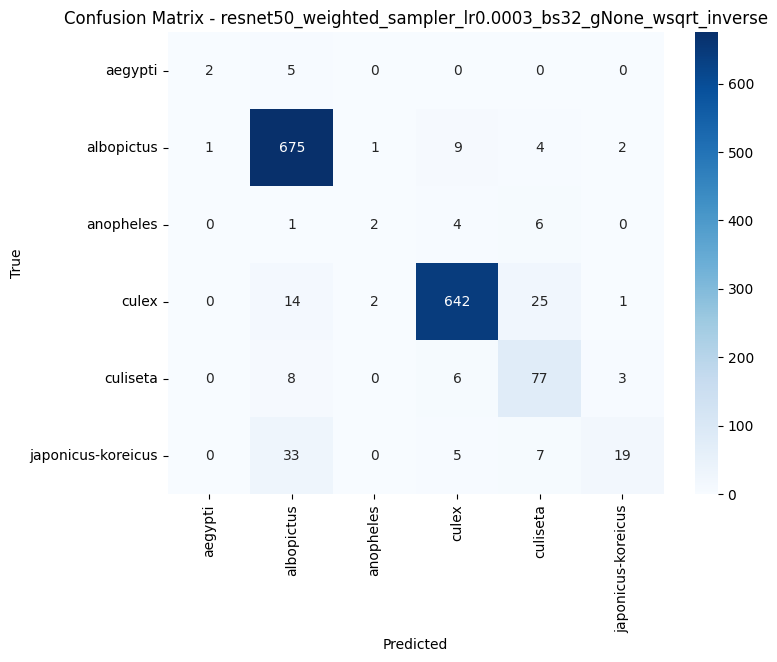


Detailed Evaluation: resnet50_weighted_sampler_lr0.0001_bs32_gNone_wsqrt_inverse
Accuracy:           0.9028
Balanced Accuracy:  0.5705
Macro Precision:    0.6570
Macro Recall:       0.5705
Macro F1:           0.5989
Weighted Precision: 0.8958
Weighted Recall:    0.9028
Weighted F1:        0.8975

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.250000  0.142857  0.181818        7
1          albopictus   0.935860  0.927746  0.931785      692
2           anopheles   0.500000  0.230769  0.315789       13
3               culex   0.919220  0.964912  0.941512      684
4            culiseta   0.727273  0.765957  0.746114       94
5  japonicus-koreicus   0.609756  0.390625  0.476190       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2500    0.1429    0.1818         7
        albopictus     0.9359    0.9277    0.9318       692
         anopheles     0.5000    0.2308    

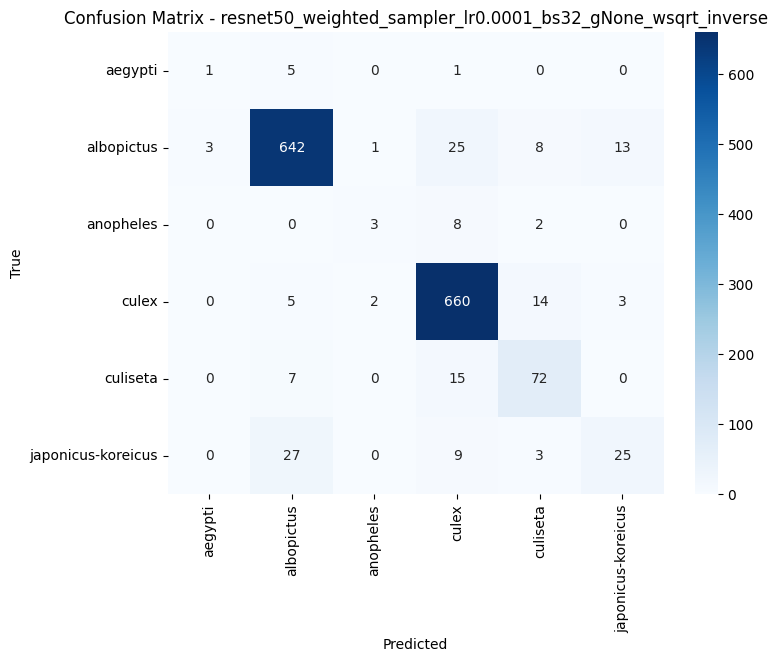


Detailed Evaluation: resnet50_weighted_loss_lr0.0003_bs32_gNone_wsqrt_inverse
Accuracy:           0.9163
Balanced Accuracy:  0.5714
Macro Precision:    0.5774
Macro Recall:       0.5714
Macro F1:           0.5713
Weighted Precision: 0.9098
Weighted Recall:    0.9163
Weighted F1:        0.9122

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.200000  0.142857  0.166667        7
1          albopictus   0.938028  0.962428  0.950071      692
2           anopheles   0.000000  0.000000  0.000000       13
3               culex   0.958333  0.941520  0.949853      684
4            culiseta   0.675439  0.819149  0.740385       94
5  japonicus-koreicus   0.692308  0.562500  0.620690       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2000    0.1429    0.1667         7
        albopictus     0.9380    0.9624    0.9501       692
         anopheles     0.0000    0.0000    0.0

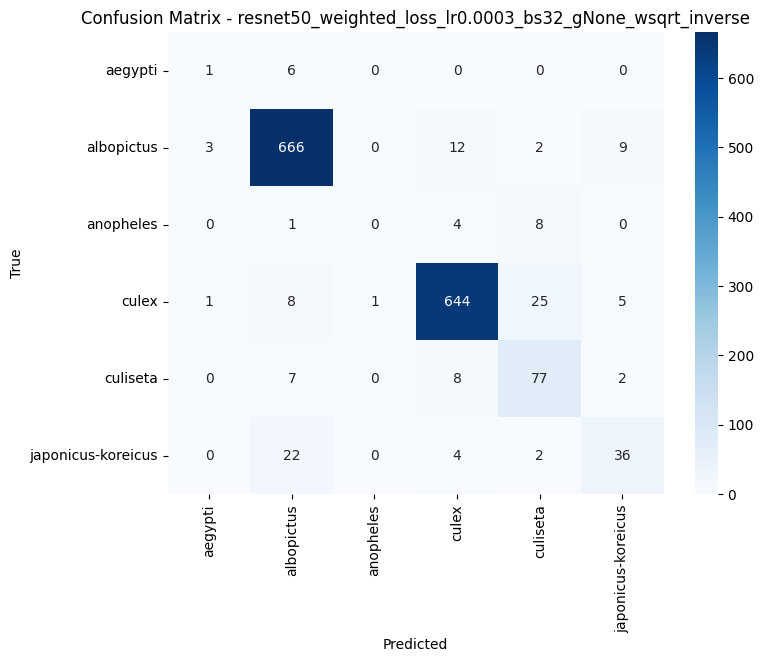


Detailed Evaluation: resnet50_weighted_loss_lr0.0001_bs32_gNone_wsqrt_inverse
Accuracy:           0.8990
Balanced Accuracy:  0.5913
Macro Precision:    0.6534
Macro Recall:       0.5913
Macro F1:           0.5971
Weighted Precision: 0.9043
Weighted Recall:    0.8990
Weighted F1:        0.8994

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.333333  0.142857  0.200000        7
1          albopictus   0.958841  0.908960  0.933234      692
2           anopheles   0.500000  0.153846  0.235294       13
3               culex   0.926450  0.957602  0.941769      684
4            culiseta   0.744444  0.712766  0.728261       94
5  japonicus-koreicus   0.457447  0.671875  0.544304       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.3333    0.1429    0.2000         7
        albopictus     0.9588    0.9090    0.9332       692
         anopheles     0.5000    0.1538    0.2

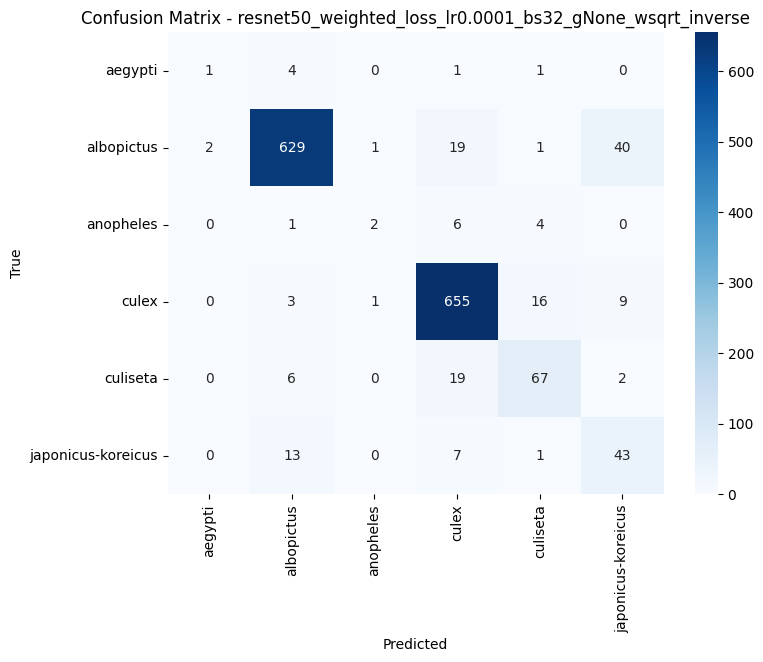


Detailed Evaluation: resnet50_pf_loss_lr0.0003_bs32_gNone_wNone
Accuracy:           0.8153
Balanced Accuracy:  0.6200
Macro Precision:    0.5155
Macro Recall:       0.6200
Macro F1:           0.5269
Weighted Precision: 0.9030
Weighted Recall:    0.8153
Weighted F1:        0.8455

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.250000  0.142857  0.181818        7
1          albopictus   0.973166  0.786127  0.869704      692
2           anopheles   0.108108  0.307692  0.160000       13
3               culex   0.964052  0.862573  0.910494      684
4            culiseta   0.539007  0.808511  0.646809       94
5  japonicus-koreicus   0.258706  0.812500  0.392453       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2500    0.1429    0.1818         7
        albopictus     0.9732    0.7861    0.8697       692
         anopheles     0.1081    0.3077    0.1600        13


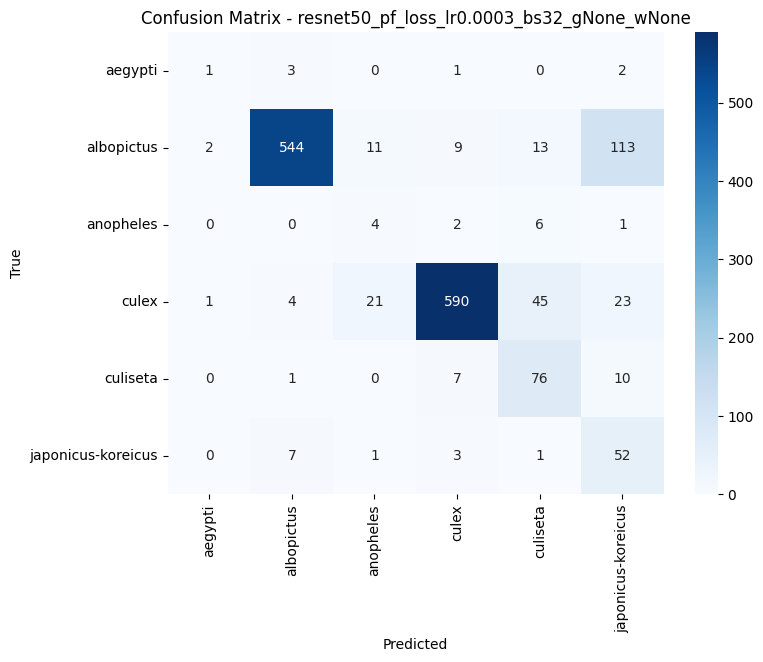


Detailed Evaluation: resnet50_pf_loss_lr0.0001_bs32_gNone_wNone
Accuracy:           0.8230
Balanced Accuracy:  0.6064
Macro Precision:    0.4998
Macro Recall:       0.6064
Macro F1:           0.5239
Weighted Precision: 0.8919
Weighted Recall:    0.8230
Weighted F1:        0.8462

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.222222  0.285714  0.250000        7
1          albopictus   0.948675  0.828035  0.884259      692
2           anopheles   0.090909  0.076923  0.083333       13
3               culex   0.969697  0.842105  0.901408      684
4            culiseta   0.481013  0.808511  0.603175       94
5  japonicus-koreicus   0.286517  0.796875  0.421488       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2222    0.2857    0.2500         7
        albopictus     0.9487    0.8280    0.8843       692
         anopheles     0.0909    0.0769    0.0833        13


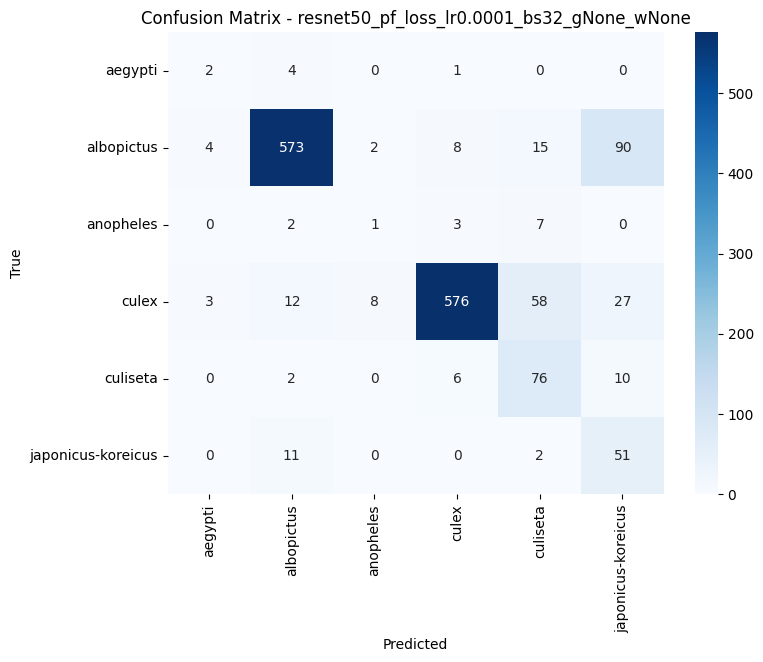


Detailed Evaluation: resnet50_stratified_sampling_lr0.0003_bs32_gNone_wNone
Accuracy:           0.9093
Balanced Accuracy:  0.5824
Macro Precision:    0.7839
Macro Recall:       0.5824
Macro F1:           0.6031
Weighted Precision: 0.9095
Weighted Recall:    0.9093
Weighted F1:        0.9059

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   1.000000  0.142857  0.250000        7
1          albopictus   0.960486  0.913295  0.936296      692
2           anopheles   0.500000  0.076923  0.133333       13
3               culex   0.916209  0.975146  0.944759      684
4            culiseta   0.784946  0.776596  0.780749       94
5  japonicus-koreicus   0.541667  0.609375  0.573529       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     1.0000    0.1429    0.2500         7
        albopictus     0.9605    0.9133    0.9363       692
         anopheles     0.5000    0.0769    0.133

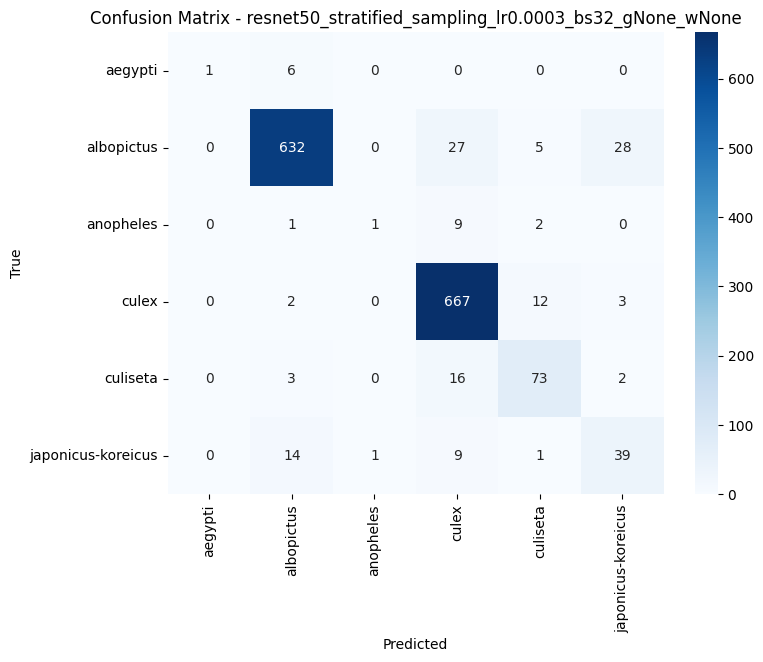


Detailed Evaluation: resnet50_stratified_sampling_lr0.0001_bs32_gNone_wNone
Accuracy:           0.8900
Balanced Accuracy:  0.5318
Macro Precision:    0.6814
Macro Recall:       0.5318
Macro F1:           0.5488
Weighted Precision: 0.8894
Weighted Recall:    0.8900
Weighted F1:        0.8864

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   1.000000  0.142857  0.250000        7
1          albopictus   0.941704  0.910405  0.925790      692
2           anopheles   0.000000  0.000000  0.000000       13
3               culex   0.906465  0.963450  0.934089      684
4            culiseta   0.800000  0.595745  0.682927       94
5  japonicus-koreicus   0.440476  0.578125  0.500000       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     1.0000    0.1429    0.2500         7
        albopictus     0.9417    0.9104    0.9258       692
         anopheles     0.0000    0.0000    0.000

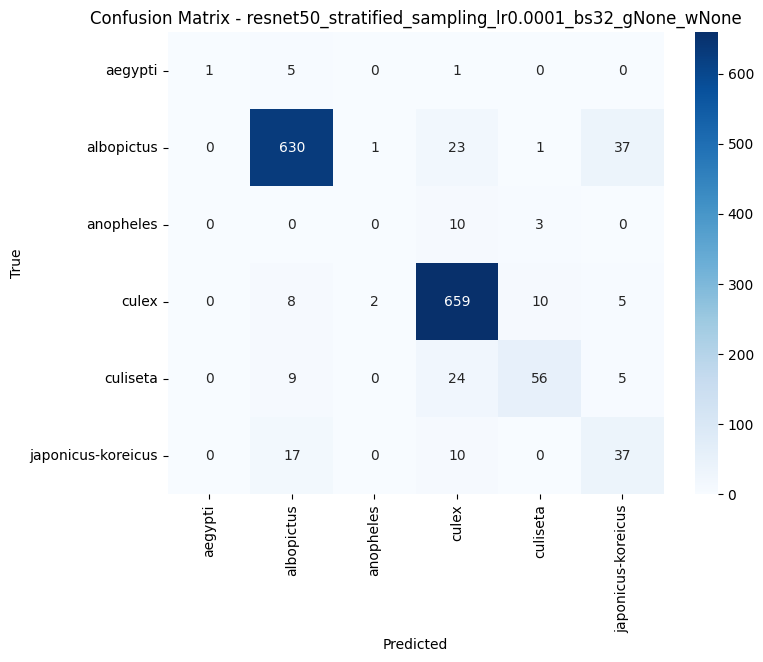


Detailed Evaluation: resnet50_stratified_weighted_loss_lr0.0003_bs32_gNone_wsqrt_inverse
Accuracy:           0.9015
Balanced Accuracy:  0.5674
Macro Precision:    0.5687
Macro Recall:       0.5674
Macro F1:           0.5641
Weighted Precision: 0.9005
Weighted Recall:    0.9015
Weighted F1:        0.9001

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.000000  0.000000  0.000000        7
1          albopictus   0.948529  0.932081  0.940233      692
2           anopheles   0.333333  0.230769  0.272727       13
3               culex   0.940233  0.942982  0.941606      684
4            culiseta   0.644628  0.829787  0.725581       94
5  japonicus-koreicus   0.545455  0.468750  0.504202       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0000    0.0000    0.0000         7
        albopictus     0.9485    0.9321    0.9402       692
         anopheles     0.3333    0.

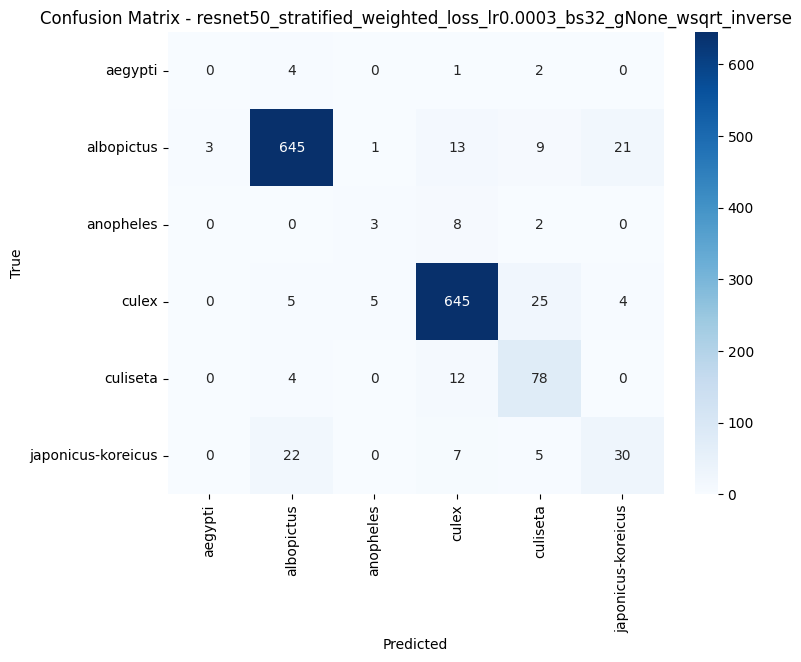


Detailed Evaluation: resnet50_stratified_weighted_loss_lr0.0001_bs32_gNone_wsqrt_inverse
Accuracy:           0.9022
Balanced Accuracy:  0.5775
Macro Precision:    0.6680
Macro Recall:       0.5775
Macro F1:           0.5966
Weighted Precision: 0.9007
Weighted Recall:    0.9022
Weighted F1:        0.9003

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.500000  0.142857  0.222222        7
1          albopictus   0.943870  0.923410  0.933528      692
2           anopheles   0.400000  0.153846  0.222222       13
3               culex   0.930496  0.959064  0.944564      684
4            culiseta   0.747253  0.723404  0.735135       94
5  japonicus-koreicus   0.486486  0.562500  0.521739       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.5000    0.1429    0.2222         7
        albopictus     0.9439    0.9234    0.9335       692
         anopheles     0.4000    0.

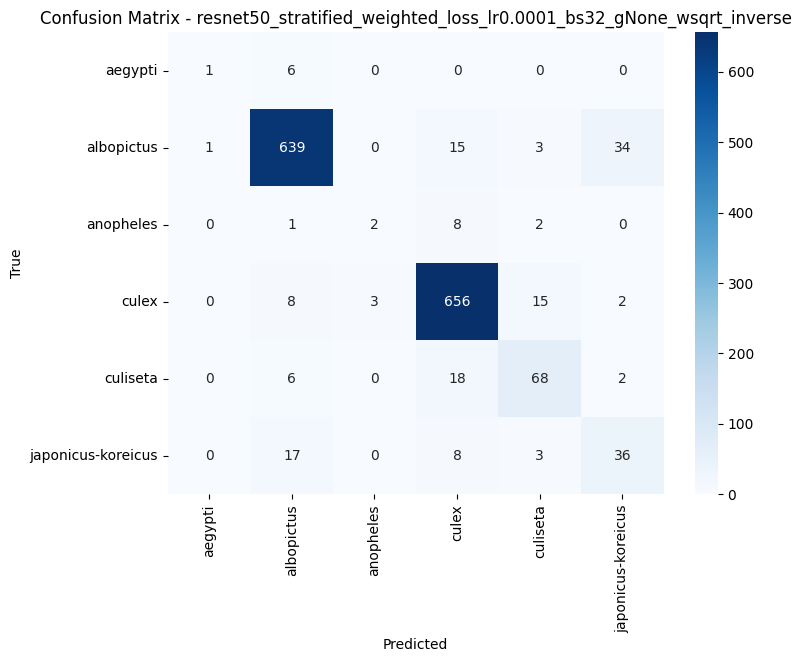

In [20]:
# detailed imbalance evaluation

detailed_eval_list = []

for model_name, data in all_test_results.items():
    print(f"\n==============================")
    print(f"Detailed Evaluation: {model_name}")
    print(f"==============================")

    all_preds = data["preds"]
    all_labels = data["labels"]
    all_probs = data["probs"]

    # Overall metrics
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)

    precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average=None,
        zero_division=0
    )

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Print overall metrics
    print(f"Accuracy:           {acc:.4f}")
    print(f"Balanced Accuracy:  {bal_acc:.4f}")
    print(f"Macro Precision:    {precision_macro:.4f}")
    print(f"Macro Recall:       {recall_macro:.4f}")
    print(f"Macro F1:           {f1_macro:.4f}")
    print(f"Weighted Precision: {precision_weighted:.4f}")
    print(f"Weighted Recall:    {recall_weighted:.4f}")
    print(f"Weighted F1:        {f1_weighted:.4f}")

    # Per-class table
    per_class_df = pd.DataFrame({
        "class_name": class_names,
        "precision": precision_per_class,
        "recall": recall_per_class,
        "f1": f1_per_class,
        "support": support
    })

    print("\nPer-class metrics:")
    print(per_class_df)

    print("\nClassification report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0))

    print("\nConfusion matrix:")
    print(cm)

    # Confusion matrix plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # Store overall metrics
    detailed_eval_list.append({
        "model": model_name,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted
    })

In [21]:
detailed_eval_df = pd.DataFrame(detailed_eval_list)

print("\n===== Detailed Evaluation Summary =====")
print(detailed_eval_df.sort_values(by="macro_f1", ascending=False))


===== Detailed Evaluation Summary =====
                                               model  accuracy  \
0  resnet50_weighted_sampler_lr0.0003_bs32_gNone_...  0.911840   
6  resnet50_stratified_sampling_lr0.0003_bs32_gNo...  0.909266   
1  resnet50_weighted_sampler_lr0.0001_bs32_gNone_...  0.902831   
3  resnet50_weighted_loss_lr0.0001_bs32_gNone_wsq...  0.898970   
9  resnet50_stratified_weighted_loss_lr0.0001_bs3...  0.902188   
2  resnet50_weighted_loss_lr0.0003_bs32_gNone_wsq...  0.916345   
8  resnet50_stratified_weighted_loss_lr0.0003_bs3...  0.901544   
7  resnet50_stratified_sampling_lr0.0001_bs32_gNo...  0.889961   
4         resnet50_pf_loss_lr0.0003_bs32_gNone_wNone  0.815315   
5         resnet50_pf_loss_lr0.0001_bs32_gNone_wNone  0.823037   

   balanced_accuracy  macro_precision  macro_recall  macro_f1  \
0           0.578269         0.725802      0.578269  0.611447   
6           0.582365         0.783885      0.582365  0.603111   
1           0.570478         0.657018

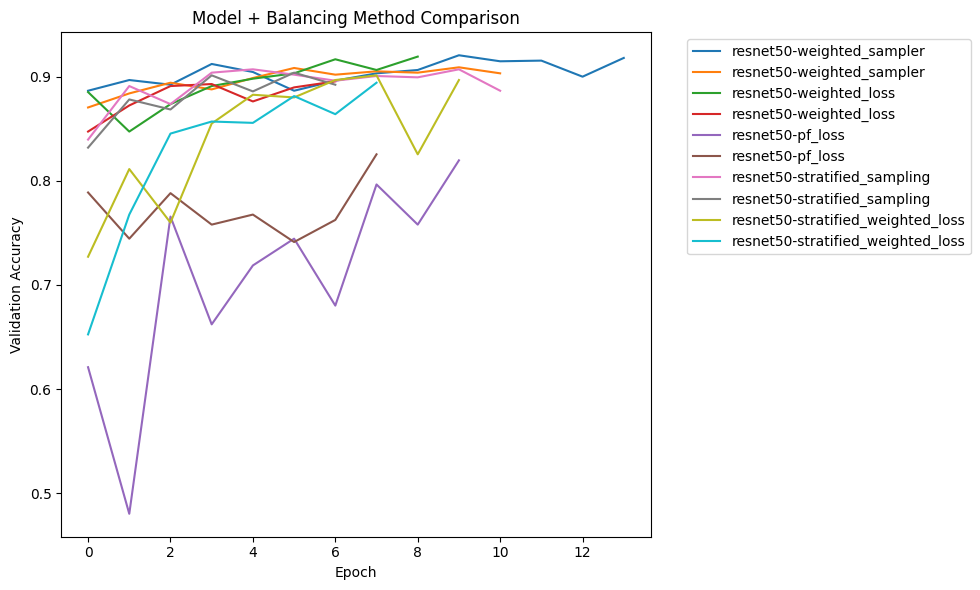

resnet50 + weighted_sampler → Best: 0.9208
resnet50 + weighted_sampler → Best: 0.9093
resnet50 + weighted_loss → Best: 0.9196
resnet50 + weighted_loss → Best: 0.8958
resnet50 + pf_loss → Best: 0.8198
resnet50 + pf_loss → Best: 0.8256
resnet50 + stratified_sampling → Best: 0.9073
resnet50 + stratified_sampling → Best: 0.9041
resnet50 + stratified_weighted_loss → Best: 0.9015
resnet50 + stratified_weighted_loss → Best: 0.8945


In [22]:
# validation accuracy plot
plt.figure(figsize=(10,6))

for r in all_results:
    label = f"{r['model']}-{r['method']}"
    plt.plot(r["val_acc_history"], label=label)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Model + Balancing Method Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.tight_layout()
plt.show()

for r in all_results:
    print(f"{r['model']} + {r['method']} → Best: {r['best_val_acc']:.4f}")



===== Results for resnet50_weighted_sampler_lr0.0003_bs32_gNone_wsqrt_inverse =====
Test Accuracy: 0.9118
           class_name  precision    recall        f1  support
0             aegypti   0.666667  0.285714  0.400000        7
1          albopictus   0.917120  0.975434  0.945378      692
2           anopheles   0.400000  0.153846  0.222222       13
3               culex   0.963964  0.938596  0.951111      684
4            culiseta   0.647059  0.819149  0.723005       94
5  japonicus-koreicus   0.760000  0.296875  0.426966       64


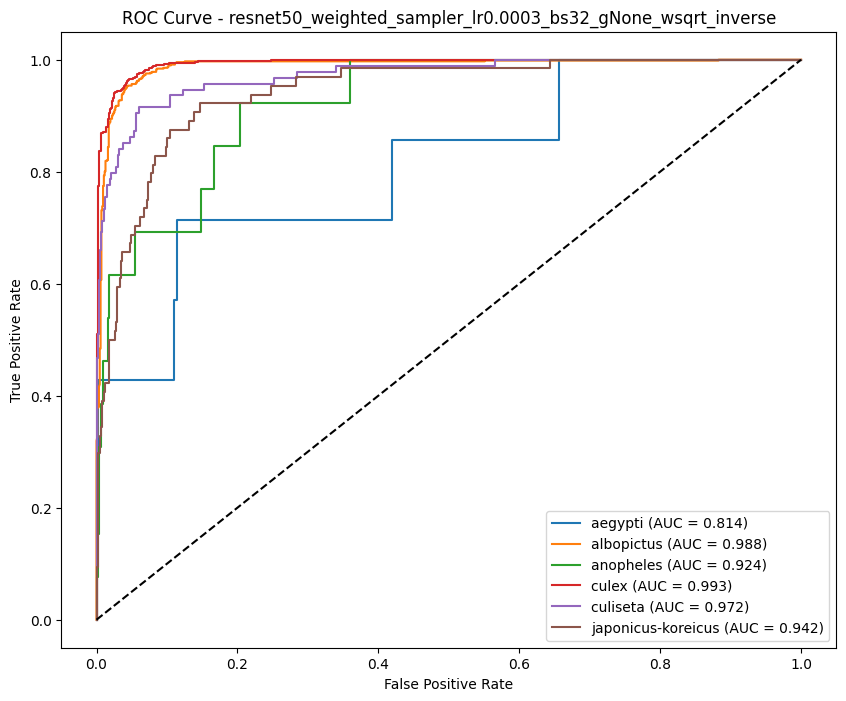

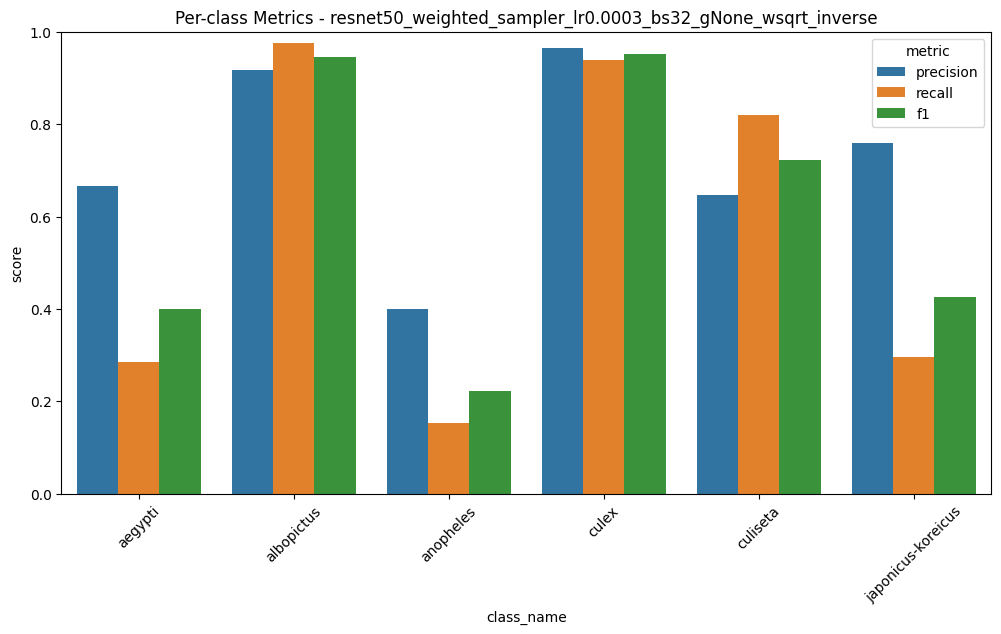


===== Results for resnet50_weighted_sampler_lr0.0001_bs32_gNone_wsqrt_inverse =====
Test Accuracy: 0.9028
           class_name  precision    recall        f1  support
0             aegypti   0.250000  0.142857  0.181818        7
1          albopictus   0.935860  0.927746  0.931785      692
2           anopheles   0.500000  0.230769  0.315789       13
3               culex   0.919220  0.964912  0.941512      684
4            culiseta   0.727273  0.765957  0.746114       94
5  japonicus-koreicus   0.609756  0.390625  0.476190       64


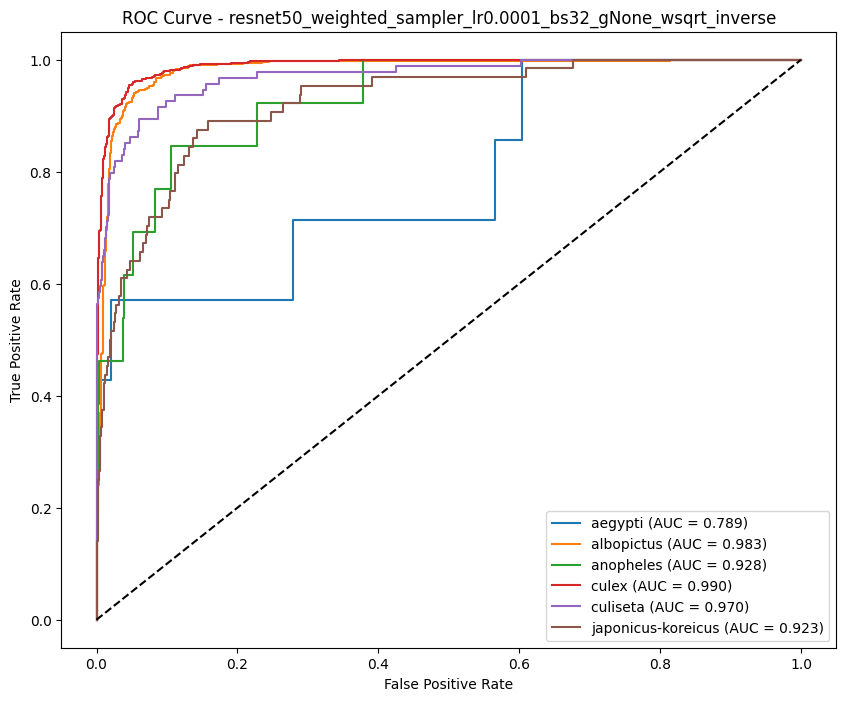

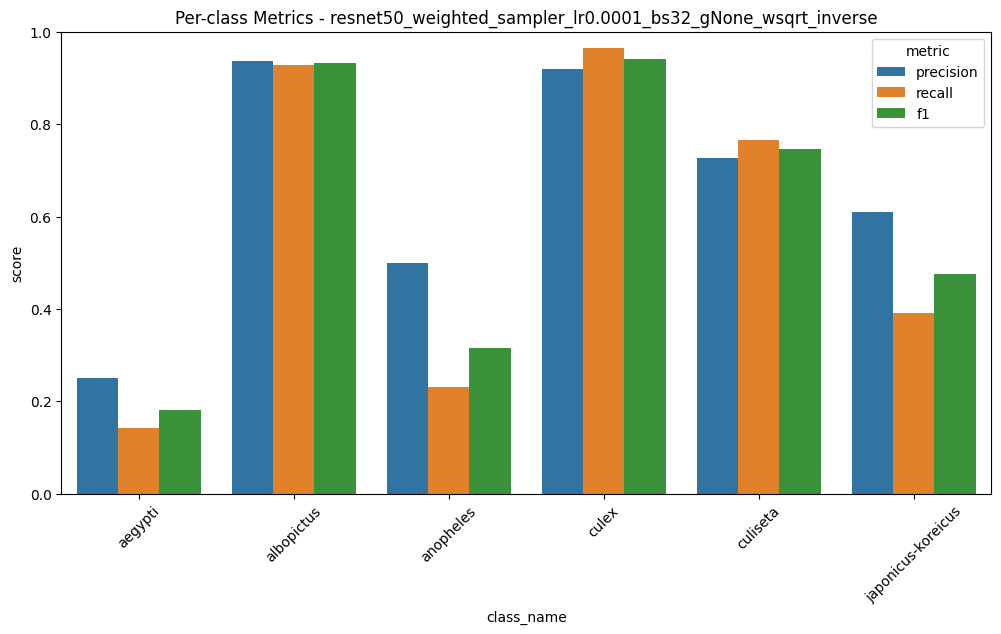


===== Results for resnet50_weighted_loss_lr0.0003_bs32_gNone_wsqrt_inverse =====
Test Accuracy: 0.9163
           class_name  precision    recall        f1  support
0             aegypti   0.200000  0.142857  0.166667        7
1          albopictus   0.938028  0.962428  0.950071      692
2           anopheles   0.000000  0.000000  0.000000       13
3               culex   0.958333  0.941520  0.949853      684
4            culiseta   0.675439  0.819149  0.740385       94
5  japonicus-koreicus   0.692308  0.562500  0.620690       64


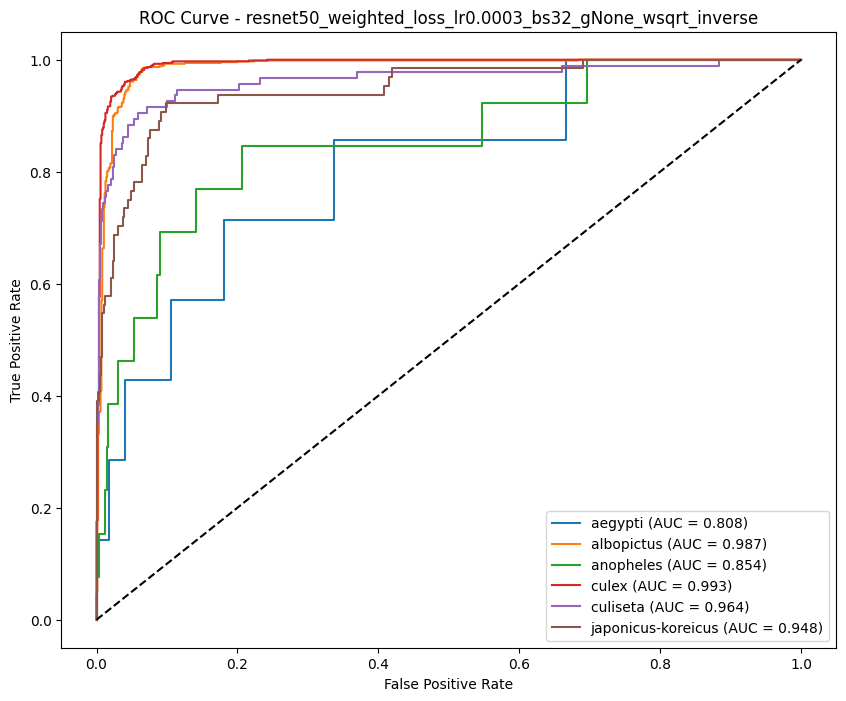

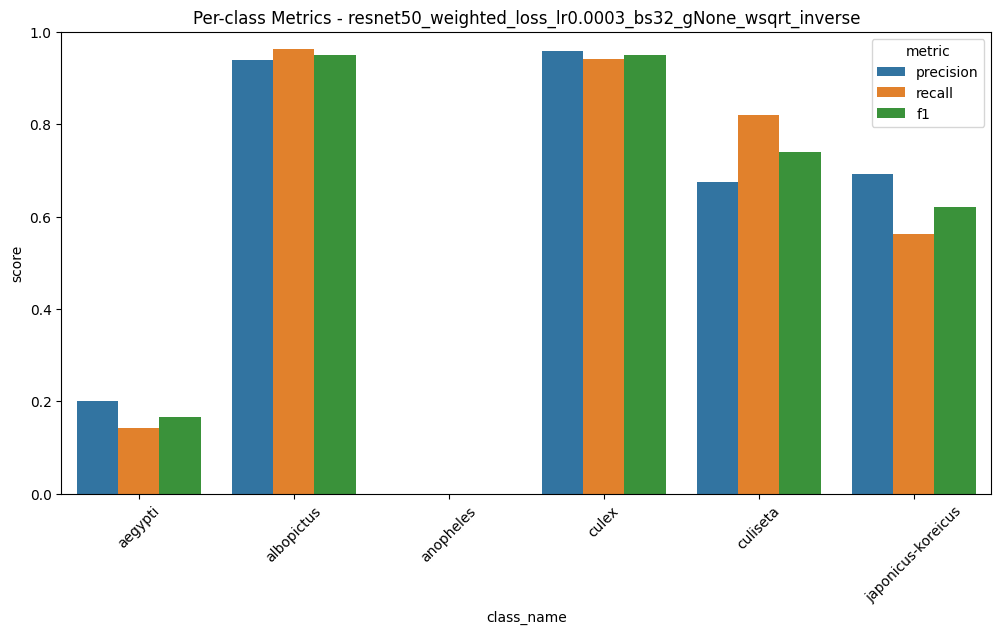


===== Results for resnet50_weighted_loss_lr0.0001_bs32_gNone_wsqrt_inverse =====
Test Accuracy: 0.899
           class_name  precision    recall        f1  support
0             aegypti   0.333333  0.142857  0.200000        7
1          albopictus   0.958841  0.908960  0.933234      692
2           anopheles   0.500000  0.153846  0.235294       13
3               culex   0.926450  0.957602  0.941769      684
4            culiseta   0.744444  0.712766  0.728261       94
5  japonicus-koreicus   0.457447  0.671875  0.544304       64


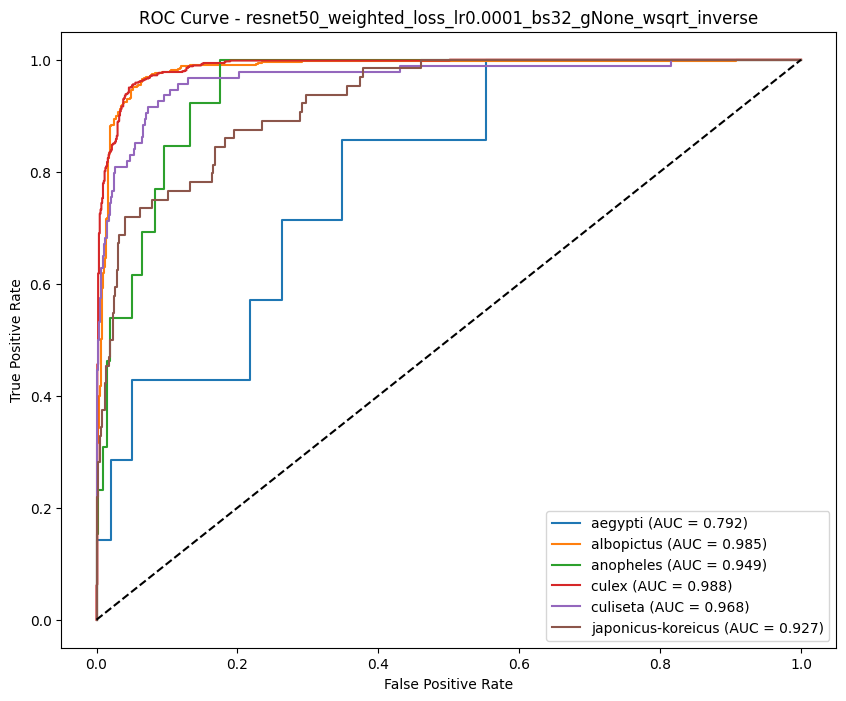

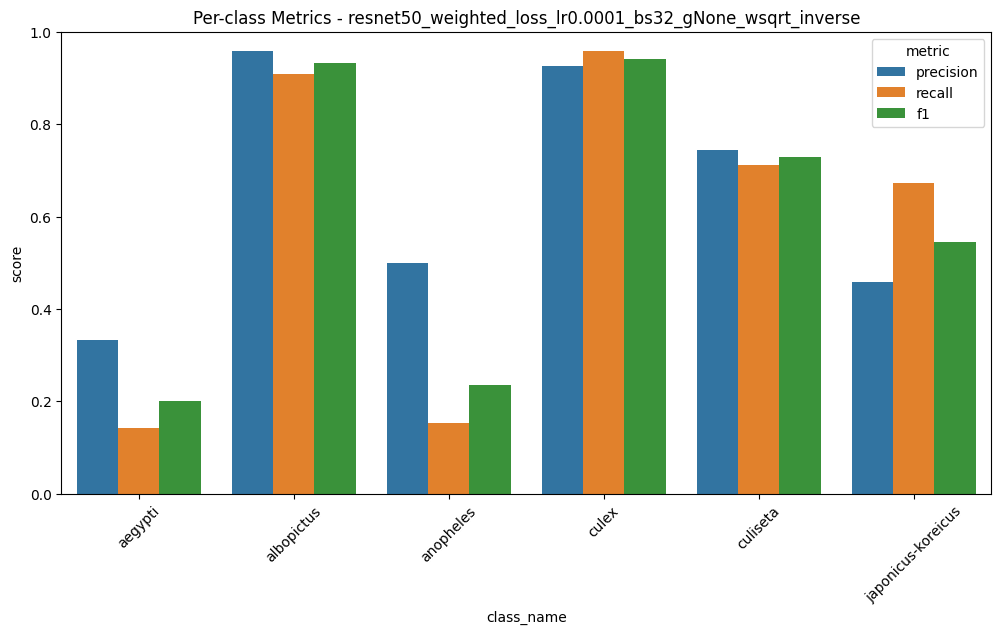


===== Results for resnet50_pf_loss_lr0.0003_bs32_gNone_wNone =====
Test Accuracy: 0.8153
           class_name  precision    recall        f1  support
0             aegypti   0.250000  0.142857  0.181818        7
1          albopictus   0.973166  0.786127  0.869704      692
2           anopheles   0.108108  0.307692  0.160000       13
3               culex   0.964052  0.862573  0.910494      684
4            culiseta   0.539007  0.808511  0.646809       94
5  japonicus-koreicus   0.258706  0.812500  0.392453       64


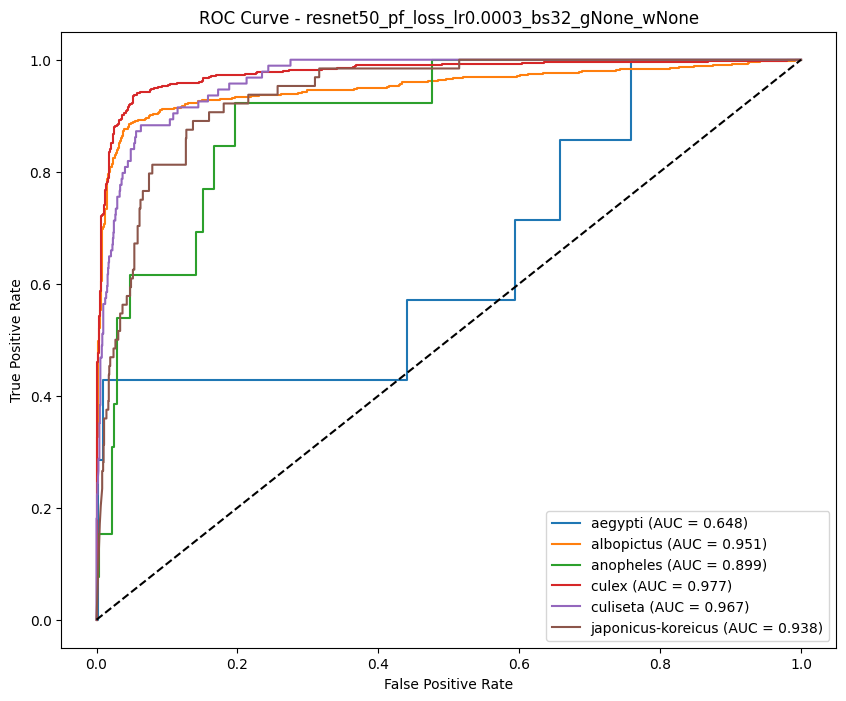

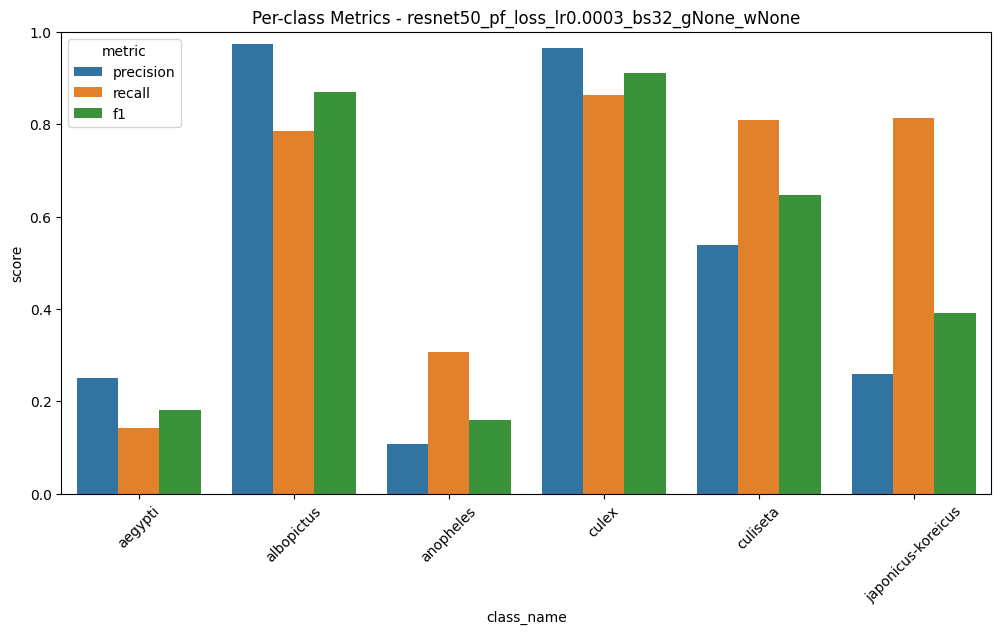


===== Results for resnet50_pf_loss_lr0.0001_bs32_gNone_wNone =====
Test Accuracy: 0.823
           class_name  precision    recall        f1  support
0             aegypti   0.222222  0.285714  0.250000        7
1          albopictus   0.948675  0.828035  0.884259      692
2           anopheles   0.090909  0.076923  0.083333       13
3               culex   0.969697  0.842105  0.901408      684
4            culiseta   0.481013  0.808511  0.603175       94
5  japonicus-koreicus   0.286517  0.796875  0.421488       64


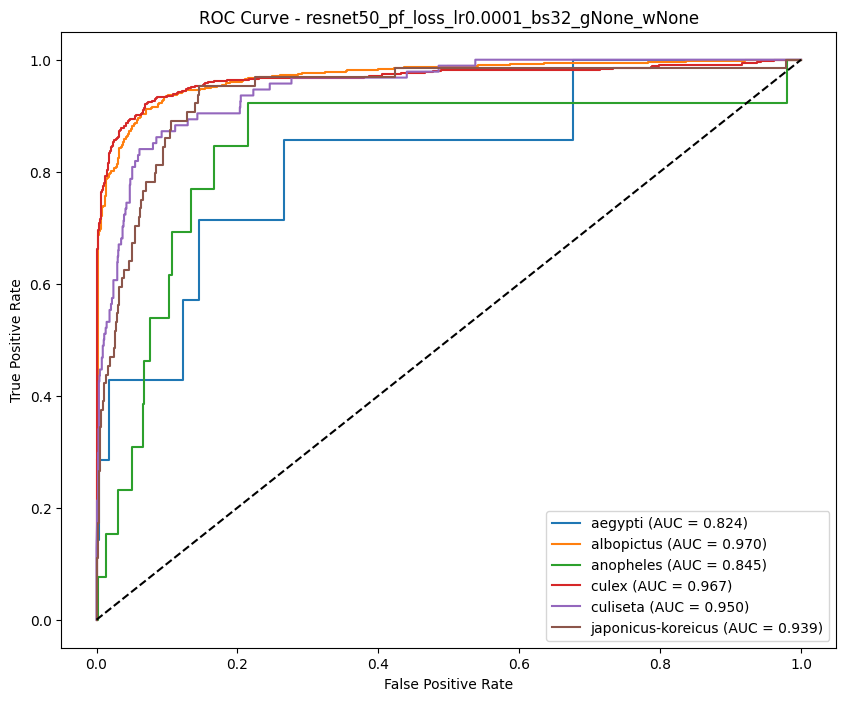

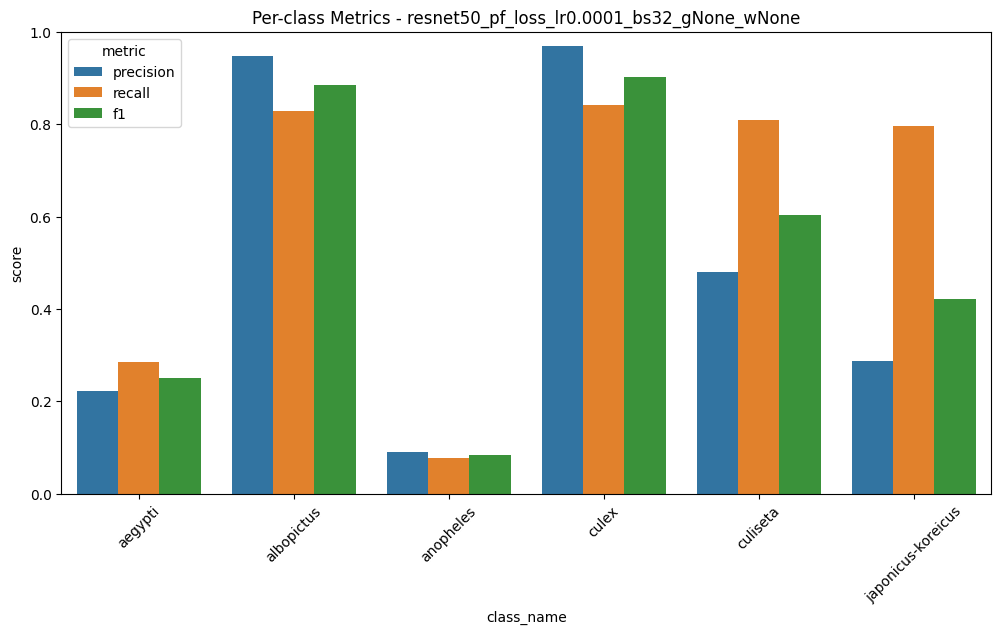


===== Results for resnet50_stratified_sampling_lr0.0003_bs32_gNone_wNone =====
Test Accuracy: 0.9093
           class_name  precision    recall        f1  support
0             aegypti   1.000000  0.142857  0.250000        7
1          albopictus   0.960486  0.913295  0.936296      692
2           anopheles   0.500000  0.076923  0.133333       13
3               culex   0.916209  0.975146  0.944759      684
4            culiseta   0.784946  0.776596  0.780749       94
5  japonicus-koreicus   0.541667  0.609375  0.573529       64


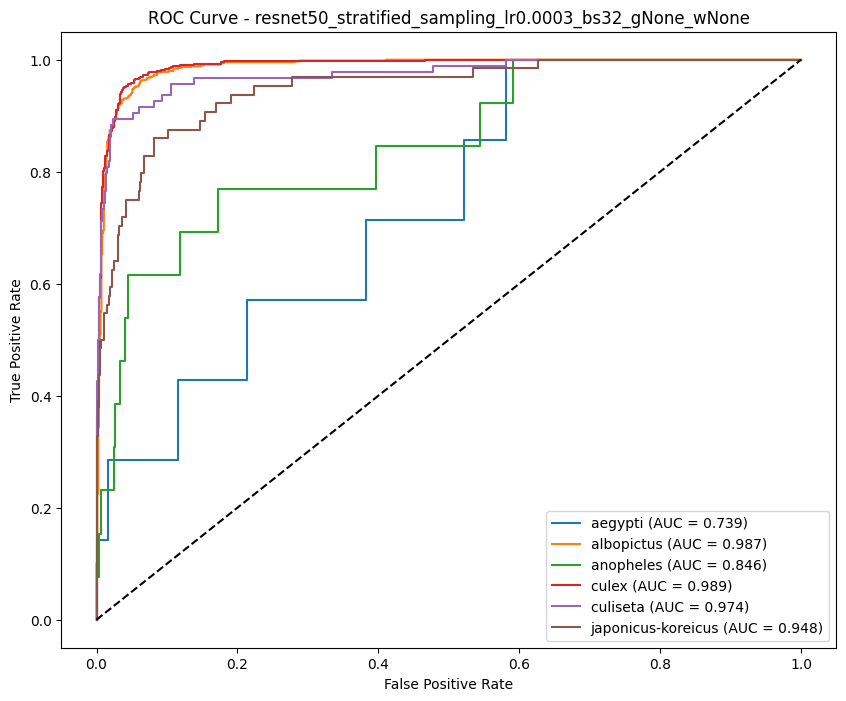

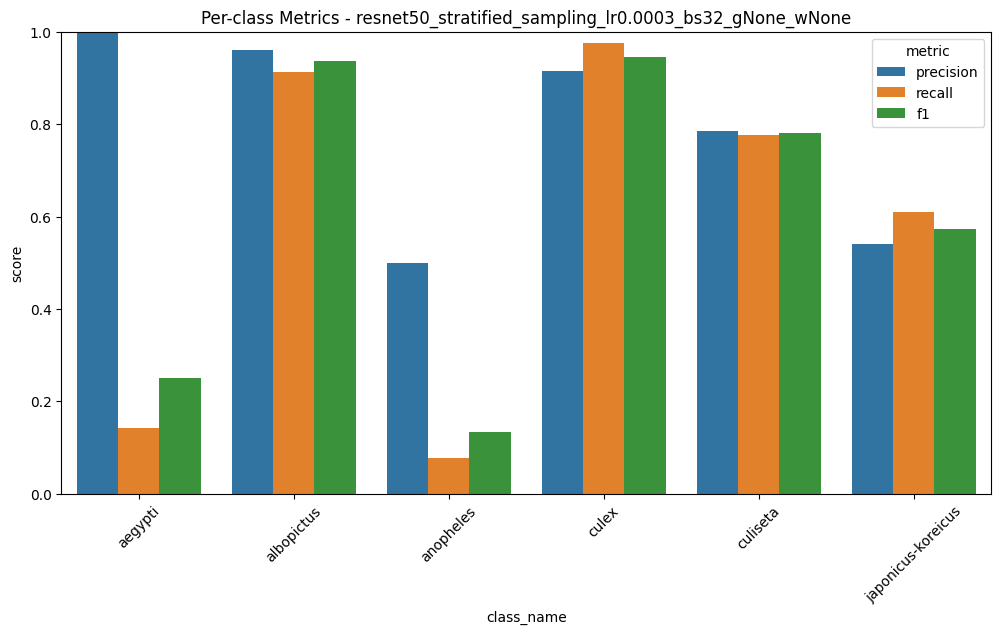


===== Results for resnet50_stratified_sampling_lr0.0001_bs32_gNone_wNone =====
Test Accuracy: 0.89
           class_name  precision    recall        f1  support
0             aegypti   1.000000  0.142857  0.250000        7
1          albopictus   0.941704  0.910405  0.925790      692
2           anopheles   0.000000  0.000000  0.000000       13
3               culex   0.906465  0.963450  0.934089      684
4            culiseta   0.800000  0.595745  0.682927       94
5  japonicus-koreicus   0.440476  0.578125  0.500000       64


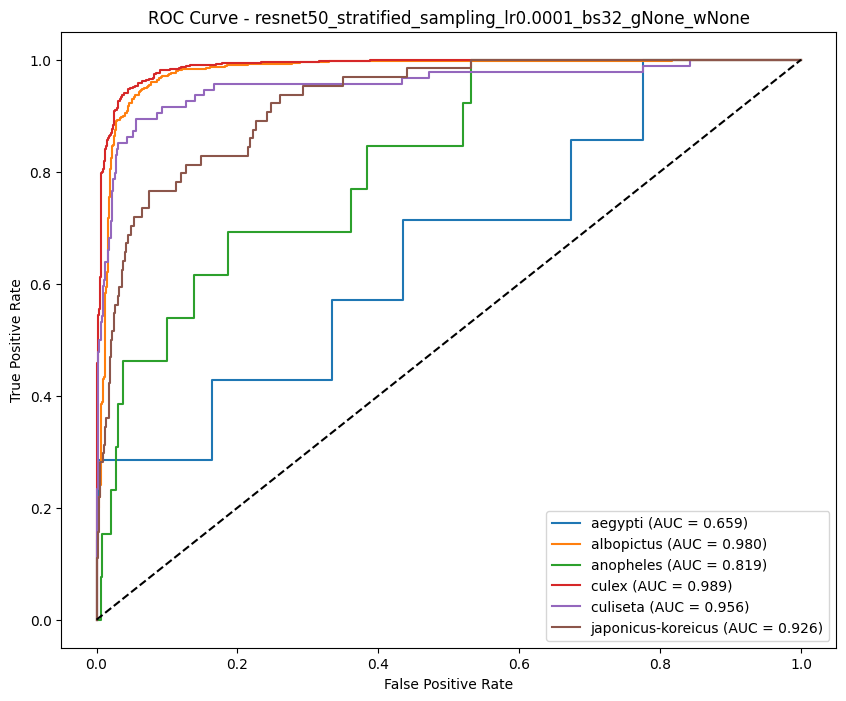

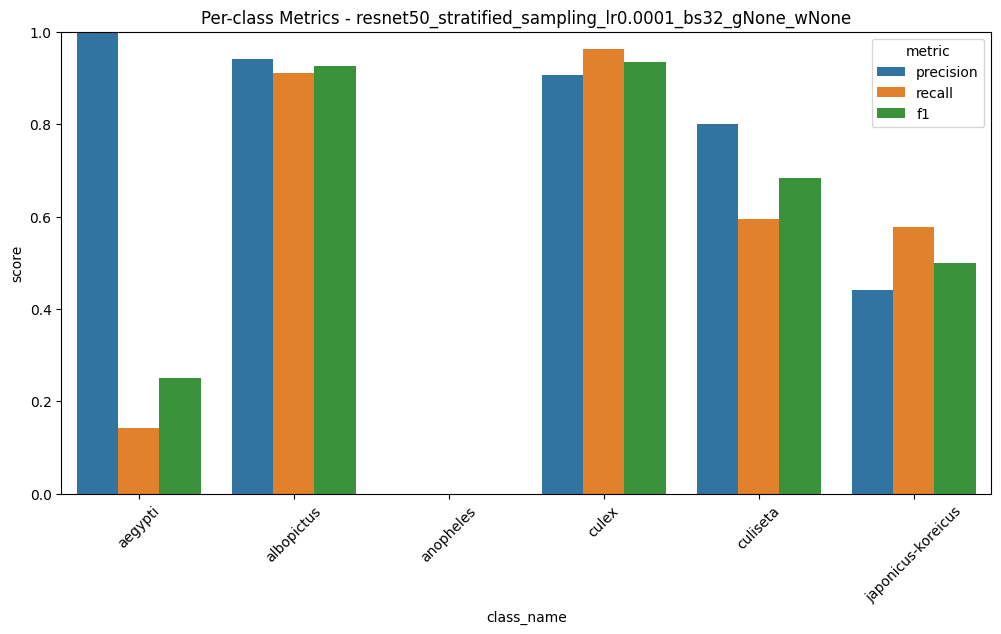


===== Results for resnet50_stratified_weighted_loss_lr0.0003_bs32_gNone_wsqrt_inverse =====
Test Accuracy: 0.9015
           class_name  precision    recall        f1  support
0             aegypti   0.000000  0.000000  0.000000        7
1          albopictus   0.948529  0.932081  0.940233      692
2           anopheles   0.333333  0.230769  0.272727       13
3               culex   0.940233  0.942982  0.941606      684
4            culiseta   0.644628  0.829787  0.725581       94
5  japonicus-koreicus   0.545455  0.468750  0.504202       64


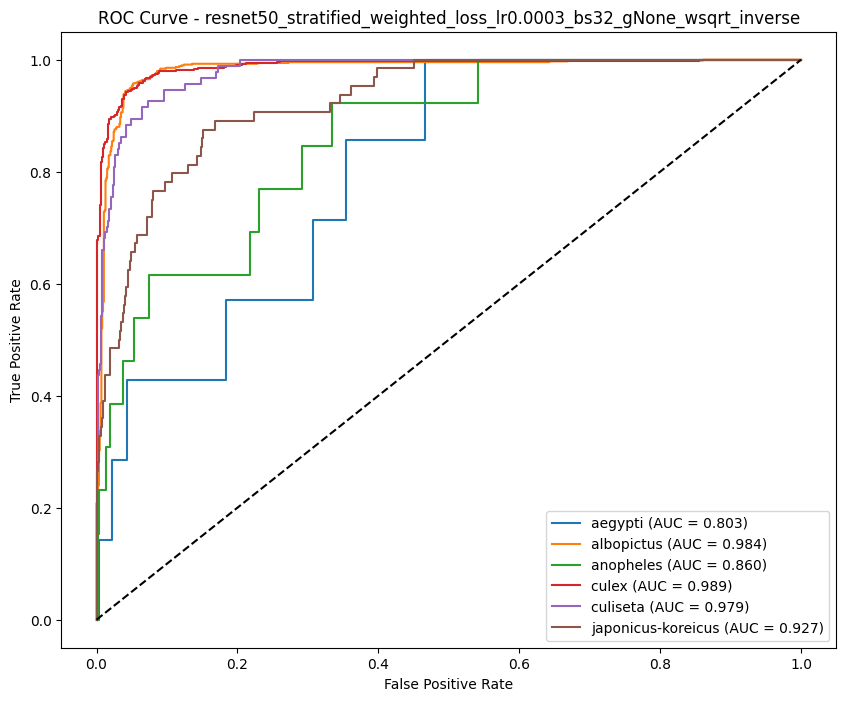

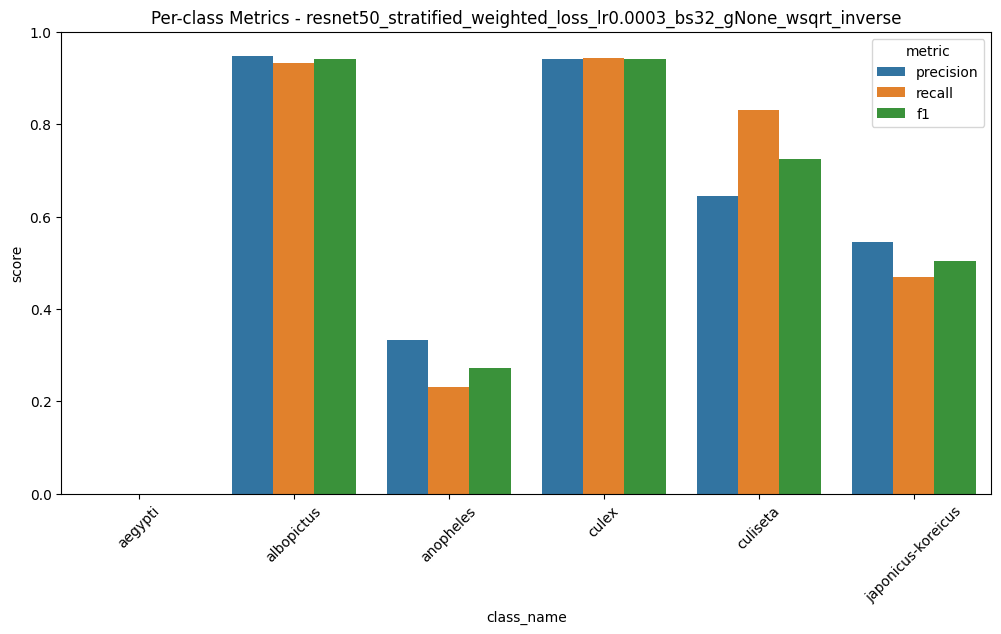


===== Results for resnet50_stratified_weighted_loss_lr0.0001_bs32_gNone_wsqrt_inverse =====
Test Accuracy: 0.9022
           class_name  precision    recall        f1  support
0             aegypti   0.500000  0.142857  0.222222        7
1          albopictus   0.943870  0.923410  0.933528      692
2           anopheles   0.400000  0.153846  0.222222       13
3               culex   0.930496  0.959064  0.944564      684
4            culiseta   0.747253  0.723404  0.735135       94
5  japonicus-koreicus   0.486486  0.562500  0.521739       64


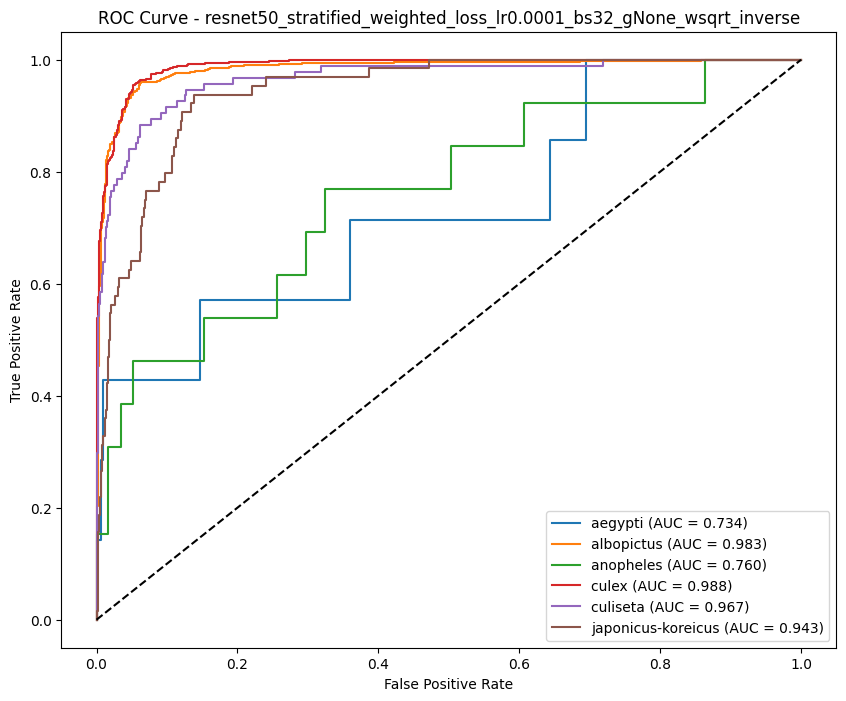

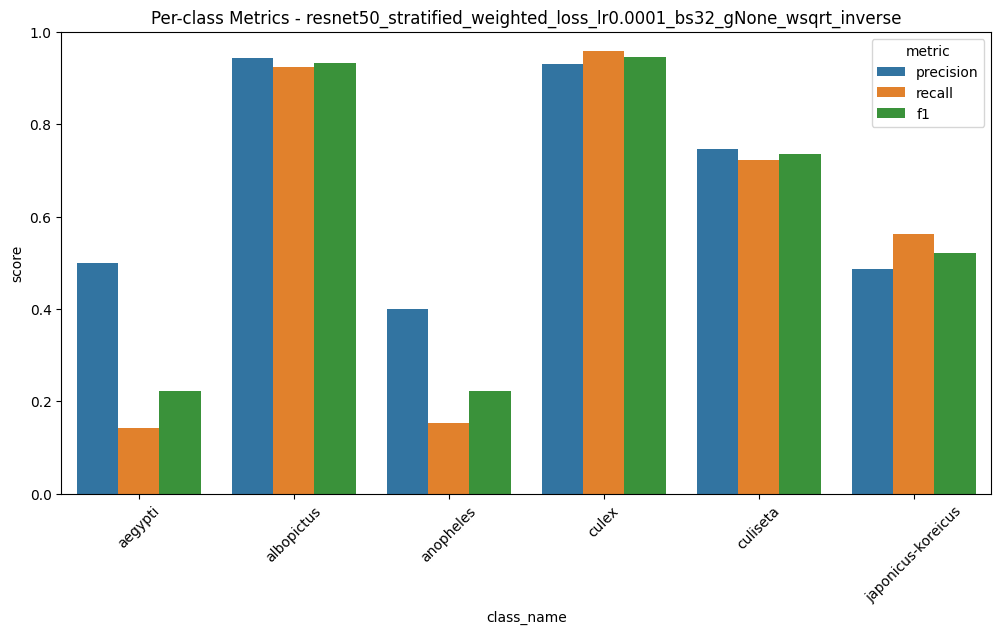

      model                    method  \
0  resnet50          weighted_sampler   
2  resnet50             weighted_loss   
1  resnet50          weighted_sampler   
6  resnet50       stratified_sampling   
7  resnet50       stratified_sampling   
8  resnet50  stratified_weighted_loss   
3  resnet50             weighted_loss   
9  resnet50  stratified_weighted_loss   
5  resnet50                   pf_loss   
4  resnet50                   pf_loss   

                                     val_acc_history  best_val_acc  \
0  [0.8867438867438867, 0.8970398970398971, 0.892...      0.920849   
2  [0.8854568854568855, 0.8474903474903475, 0.873...      0.919562   
1  [0.8706563706563707, 0.8841698841698842, 0.894...      0.909266   
6  [0.8397683397683398, 0.8912483912483913, 0.873...      0.907336   
7  [0.832046332046332, 0.8783783783783784, 0.8687...      0.904118   
8  [0.7271557271557272, 0.8114543114543115, 0.759...      0.901544   
3  [0.8474903474903475, 0.8725868725868726, 0.891...      

In [23]:
summary_list = []

for model_name, data in all_test_results.items():
    print(f"\n===== Results for {model_name} =====")

    all_preds = data["preds"]
    all_labels = data["labels"]
    all_probs = data["probs"]
    
    # ===== Accuracy =====
    acc = accuracy_score(all_labels, all_preds)
    print("Test Accuracy:", round(acc, 4))

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )
    
    # ===== Precision / Recall / F1 per class =====
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average=None,
        zero_division=0
    )

    per_class_df = pd.DataFrame({
        "class_name": class_names,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support
    })
    print(per_class_df)

    # ===== ROC Curve =====
    n_classes = len(class_names)
    all_labels_bin = label_binarize(all_labels, classes=range(n_classes))

    plt.figure(figsize=(10, 8))

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc_i:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

    # ===== Bar chart =====
    plot_df = per_class_df.melt(
        id_vars=["class_name", "support"],
        value_vars=["precision", "recall", "f1"],
        var_name="metric",
        value_name="score"
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_df, x="class_name", y="score", hue="metric")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.title(f"Per-class Metrics - {model_name}")
    plt.show()

    
    # ===== Macro metrics =====
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        all_labels,
        all_probs,
        multi_class="ovr",
        average="macro"
    )

    # ===== Store summary =====
    summary_list.append({
        "model": model_name,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "roc_auc_ovr": roc_auc
    })

df = pd.DataFrame(all_results)
print(df.sort_values(by="best_val_acc", ascending=False))

df = pd.DataFrame(summary_list)
print(df.sort_values(by="f1_macro", ascending=False))

In [24]:
summary_df = pd.DataFrame(summary_list)
print("\n===== Model Comparison Summary =====")
print(summary_df)


===== Model Comparison Summary =====
                                               model  accuracy  \
0  resnet50_weighted_sampler_lr0.0003_bs32_gNone_...  0.911840   
1  resnet50_weighted_sampler_lr0.0001_bs32_gNone_...  0.902831   
2  resnet50_weighted_loss_lr0.0003_bs32_gNone_wsq...  0.916345   
3  resnet50_weighted_loss_lr0.0001_bs32_gNone_wsq...  0.898970   
4         resnet50_pf_loss_lr0.0003_bs32_gNone_wNone  0.815315   
5         resnet50_pf_loss_lr0.0001_bs32_gNone_wNone  0.823037   
6  resnet50_stratified_sampling_lr0.0003_bs32_gNo...  0.909266   
7  resnet50_stratified_sampling_lr0.0001_bs32_gNo...  0.889961   
8  resnet50_stratified_weighted_loss_lr0.0003_bs3...  0.901544   
9  resnet50_stratified_weighted_loss_lr0.0001_bs3...  0.902188   

   precision_macro  recall_macro  f1_macro  roc_auc_ovr  
0         0.725802      0.578269  0.611447     0.938927  
1         0.657018      0.570478  0.598868     0.930613  
2         0.577351      0.571409  0.571277     0.925524  
3  

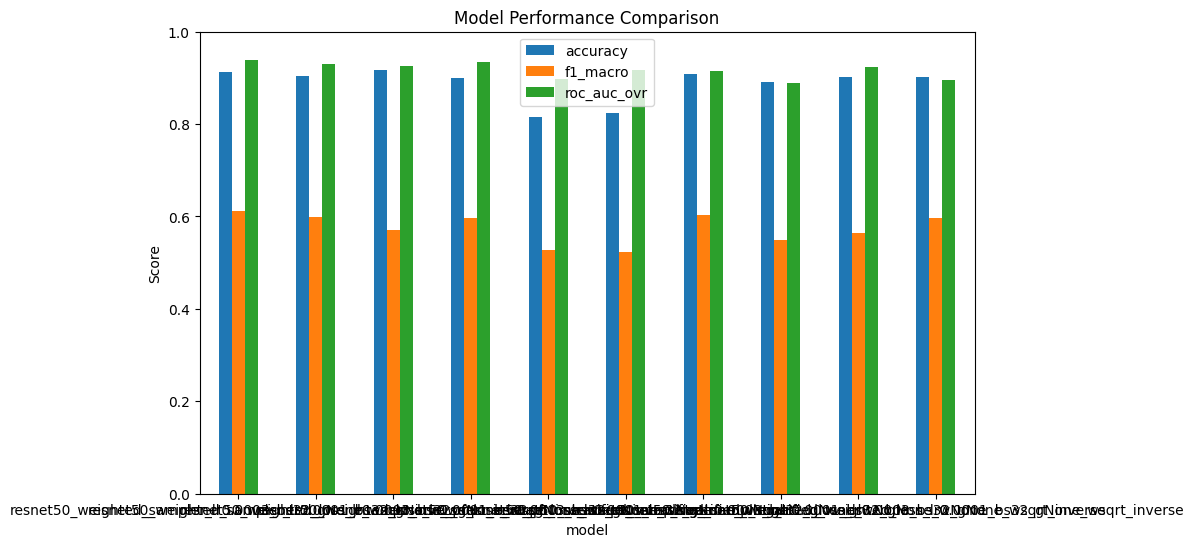

In [25]:
summary_df.set_index("model")[["accuracy", "f1_macro", "roc_auc_ovr"]].plot(
    kind="bar", figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [26]:
best = max(all_results, key=lambda x: x["best_val_acc"])

print("Best Model:", best["model"])
print("Best Method:", best["method"])
print("Best Accuracy:", best["best_val_acc"])

Best Model: resnet50
Best Method: weighted_sampler
Best Accuracy: 0.9208494208494209
